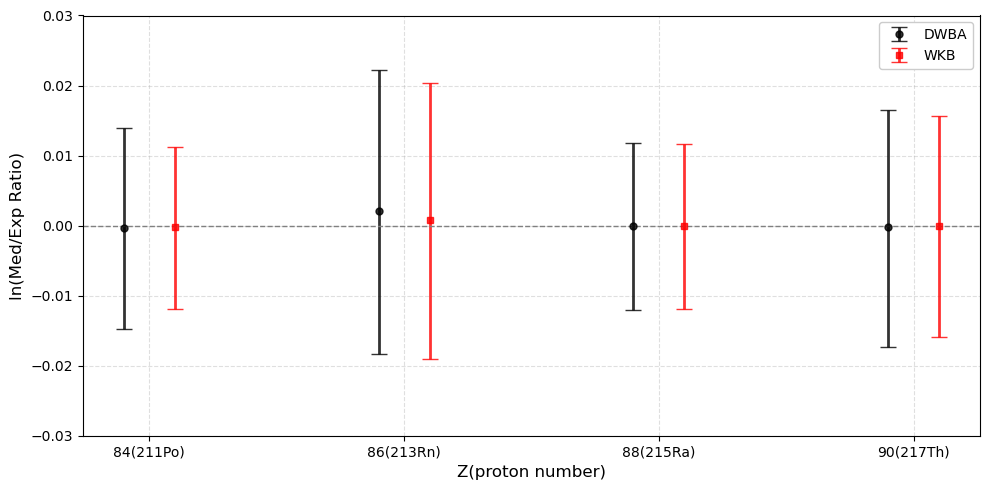

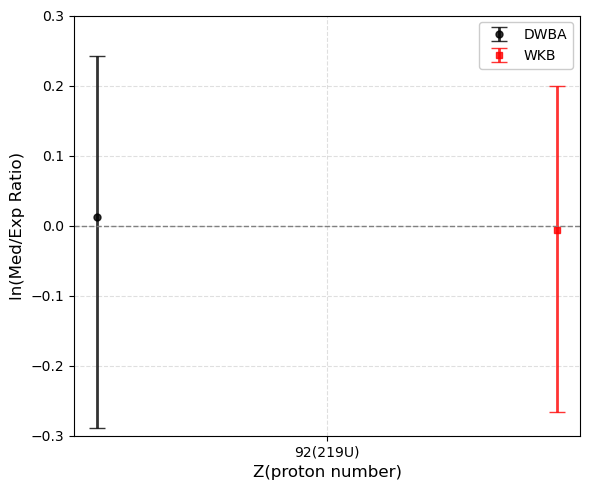

In [42]:
import numpy as np
import matplotlib.pyplot as plt


Sys=['211Po','213Rn','215Ra','217Th','219U']
Z=[84,86,88,90,92]
T_half_expt=[0.516,19.36e-3,1.68e-3,254e-6,60e-6]
T_half_calc_dwba=[0.515853576464293,0.01940080074073156,0.0016798746921742062,0.00025393277540573426,6.0724287680416717e-05]
T_half_2sigma_dwba=[0.007384161900277197,0.0003937785991267398,1.999598301277089e-05,4.292253948313664e-06,1.5754327577762725e-05]

T_half_calc_wkb=[0.5158905614040402,0.019376367726007926,0.0016799052057963173,0.0002540000639797968,5.960557474881356e-05]
T_half_2sigma_wkb=[0.005965097512233266,0.0003818913474164974,1.9873828913767867e-05,4.0074559194984095e-06,1.3631900306087726e-05]




# 计算两种模型的比值和误差
ratios_dwba = [np.log(calc/expt) for calc, expt in zip(T_half_calc_dwba, T_half_expt)]
ratio_errors_dwba = [np.log(sigma/expt) for sigma, expt in zip(T_half_2sigma_dwba, T_half_expt)]
ratios_wkb = [np.log(calc/expt) for calc, expt in zip(T_half_calc_wkb, T_half_expt)] 
ratio_errors_wkb = [np.log(sigma/expt) for sigma, expt in zip(T_half_2sigma_wkb, T_half_expt)]

# 计算对数转换后的误差范围（上界和下界）
error_dwba_lower = [np.log((calc-sigma)/expt) for calc, sigma, expt in zip(T_half_calc_dwba, T_half_2sigma_dwba, T_half_expt)]
error_dwba_upper = [np.log((calc+sigma)/expt) for calc, sigma, expt in zip(T_half_calc_dwba, T_half_2sigma_dwba, T_half_expt)]
error_wkb_lower = [np.log((calc-sigma)/expt) for calc, sigma, expt in zip(T_half_calc_wkb, T_half_2sigma_wkb, T_half_expt)]
error_wkb_upper = [np.log((calc+sigma)/expt) for calc, sigma, expt in zip(T_half_calc_wkb, T_half_2sigma_wkb, T_half_expt)]

# 准备误差条数据（上误差和下误差）
dwba_errors = [np.array(ratios_dwba) - np.array(error_dwba_lower), 
               np.array(error_dwba_upper) - np.array(ratios_dwba)]
wkb_errors = [np.array(ratios_wkb) - np.array(error_wkb_lower),
              np.array(error_wkb_upper) - np.array(ratios_wkb)]

# 创建第一个图形（前四个核素）
plt.figure(figsize=(10, 5))

# 绘制前四个核素的DWBA模型结果
plt.errorbar(np.array(Z[:4])-0.2, ratios_dwba[:4], yerr=[err[:4] for err in dwba_errors], fmt='o', 
            color='black', markersize=5, capsize=6, label='DWBA', 
            linewidth=2, alpha=0.8)

# 绘制前四个核素的WKB模型结果
plt.errorbar(np.array(Z[:4])+0.2, ratios_wkb[:4], yerr=[err[:4] for err in wkb_errors], fmt='s',
            color='red', markersize=5, capsize=6, label='WKB',
            linewidth=2, alpha=0.8)

# 添加参考线
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# 设置坐标轴
plt.xticks(Z[:4], [f"{z}({sys})" for z, sys in zip(Z[:4], Sys[:4])], fontsize=10)
plt.xlabel('Z(proton number)', fontsize=12)
plt.ylabel('ln(Med/Exp Ratio)', fontsize=12)
plt.ylim(-0.03, 0.03)

# 添加图例和网格
plt.legend(fontsize=10, loc='upper right', framealpha=1)
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('comparison_first_four.pdf')
plt.show()

# 创建第二个图形（最后一个核素U）
plt.figure(figsize=(6, 5))

# 绘制最后一个核素的DWBA模型结果
plt.errorbar([Z[-1]-0.2], [ratios_dwba[-1]], yerr=[[dwba_errors[0][-1]], [dwba_errors[1][-1]]], fmt='o', 
            color='black', markersize=5, capsize=6, label='DWBA', 
            linewidth=2, alpha=0.8)

# 绘制最后一个核素的WKB模型结果
plt.errorbar([Z[-1]+0.2], [ratios_wkb[-1]], yerr=[[wkb_errors[0][-1]], [wkb_errors[1][-1]]], fmt='s',
            color='red', markersize=5, capsize=6, label='WKB',
            linewidth=2, alpha=0.8)

# 添加参考线
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# 设置坐标轴
plt.xticks([Z[-1]], [f"{Z[-1]}({Sys[-1]})"], fontsize=10)
plt.xlabel('Z(proton number)', fontsize=12)
plt.ylabel('ln(Med/Exp Ratio)', fontsize=12)
plt.ylim(-0.3, 0.3)

# 添加图例和网格
plt.legend(fontsize=10, loc='upper right', framealpha=1)
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('comparison_last_one.pdf')
plt.show()